# Day-Ahead Electricity Load Forecast (Simple)
This notebook keeps the workflow simple and modular.

## 1) Imports and constants

In [1]:
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

DATA_PATH = Path('data/household_power_consumption.txt')
PLOT_PATH = Path('forecast_results_notebook.png')
TARGET_COL = 'Global_active_power'
HORIZON_HOURS = 24
RANDOM_STATE = 4

## 2) Data functions

In [2]:
def load_and_clean_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'Dataset not found at {path}')

    df = pd.read_csv(path, sep=';', na_values=['?'], low_memory=False)
    df['timestamp'] = pd.to_datetime(
        df['Date'] + ' ' + df['Time'],
        format='%d/%m/%Y %H:%M:%S',
        errors='coerce',
    )
    df = df.drop(columns=['Date', 'Time'])
    df = df.dropna(subset=['timestamp']).set_index('timestamp').sort_index()

    numeric_cols = [
        'Global_active_power', 'Global_reactive_power', 'Voltage',
        'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
    ]
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    df = df.dropna(subset=[TARGET_COL])
    df[numeric_cols] = df[numeric_cols].interpolate(limit=5)
    return df


def resample_to_hourly(df: pd.DataFrame) -> pd.DataFrame:
    hourly = pd.DataFrame(index=df.resample('h').size().index)
    hourly[TARGET_COL] = df[TARGET_COL].resample('h').sum(min_count=1)

    for col in ['Global_reactive_power', 'Voltage', 'Global_intensity']:
        hourly[col] = df[col].resample('h').mean()

    for col in ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']:
        hourly[col] = df[col].resample('h').sum(min_count=1)

    return hourly.dropna(subset=[TARGET_COL])

## 3) Feature engineering 

In [3]:
def build_features(hourly: pd.DataFrame, horizon: int = HORIZON_HOURS) -> pd.DataFrame:
    load = hourly[TARGET_COL]
    df = pd.DataFrame(index=hourly.index)

    # Core lag and trend features
    df['load_now'] = load
    df['lag_1'] = load.shift(1)
    df['lag_24'] = load.shift(24)
    df['lag_168'] = load.shift(168)
    df['roll_mean_6'] = load.shift(1).rolling(6).mean()
    df['roll_mean_24'] = load.shift(1).rolling(24).mean()

    # Day/week profile features
    df['same_hour_mean_7d'] = load.shift(24).rolling(24 * 7).mean()
    df['same_hour_std_7d'] = load.shift(24).rolling(24 * 7).std()
    df['day_total_prev'] = load.shift(24).rolling(24).sum()
    df['week_total_prev'] = load.shift(24).rolling(24 * 7).sum()
    df['diff_24'] = load.diff(24)
    df['diff_168'] = load.diff(168)

    # Known future calendar time (no leakage)
    future_idx = df.index + pd.Timedelta(hours=horizon)
    df['future_hour_sin'] = np.sin(2 * np.pi * future_idx.hour / 24)
    df['future_hour_cos'] = np.cos(2 * np.pi * future_idx.hour / 24)
    df['future_dow_sin'] = np.sin(2 * np.pi * future_idx.dayofweek / 7)
    df['future_dow_cos'] = np.cos(2 * np.pi * future_idx.dayofweek / 7)
    df['future_month_sin'] = np.sin(2 * np.pi * future_idx.month / 12)
    df['future_month_cos'] = np.cos(2 * np.pi * future_idx.month / 12)

    # Target = load 24 hours ahead
    df['target'] = load.shift(-horizon)
    return df.dropna()


def time_split(df: pd.DataFrame, test_size: float = 0.2):
    split_idx = int(len(df) * (1 - test_size))
    train_df = df.iloc[:split_idx]
    test_df = df.iloc[split_idx:]

    x_train = train_df.drop(columns=['target'])
    y_train = train_df['target']
    x_test = test_df.drop(columns=['target'])
    y_test = test_df['target']
    baseline = test_df['load_now']
    return x_train, y_train, x_test, y_test, baseline

## 4) Train and evaluate

In [4]:
def evaluate(y_true: pd.Series, y_pred: np.ndarray) -> Tuple[float, float]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return mae, rmse


minute_df = load_and_clean_data(DATA_PATH)
hourly_df = resample_to_hourly(minute_df)
model_df = build_features(hourly_df, horizon=HORIZON_HOURS)
x_train, y_train, x_test, y_test, baseline = time_split(model_df, test_size=0.2)

model = XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=2.0,
    reg_alpha=0.1,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=4,
)
model.fit(x_train, y_train)

pred = model.predict(x_test)
baseline_pred = baseline.to_numpy()

model_mae, model_rmse = evaluate(y_test, pred)
base_mae, base_rmse = evaluate(y_test, baseline_pred)
improvement = 100 * (base_mae - model_mae) / base_mae

print(f'Model MAE : {model_mae:.4f}')
print(f'Model RMSE: {model_rmse:.4f}')
print(f'Naive MAE : {base_mae:.4f}')
print(f'Naive RMSE: {base_rmse:.4f}')
print(f'MAE improvement vs baseline: {improvement:.2f}%')

Model MAE : 25.9247
Model RMSE: 35.5685
Naive MAE : 32.1622
Naive RMSE: 47.3973
MAE improvement vs baseline: 19.39%


## 5) Quick visualization

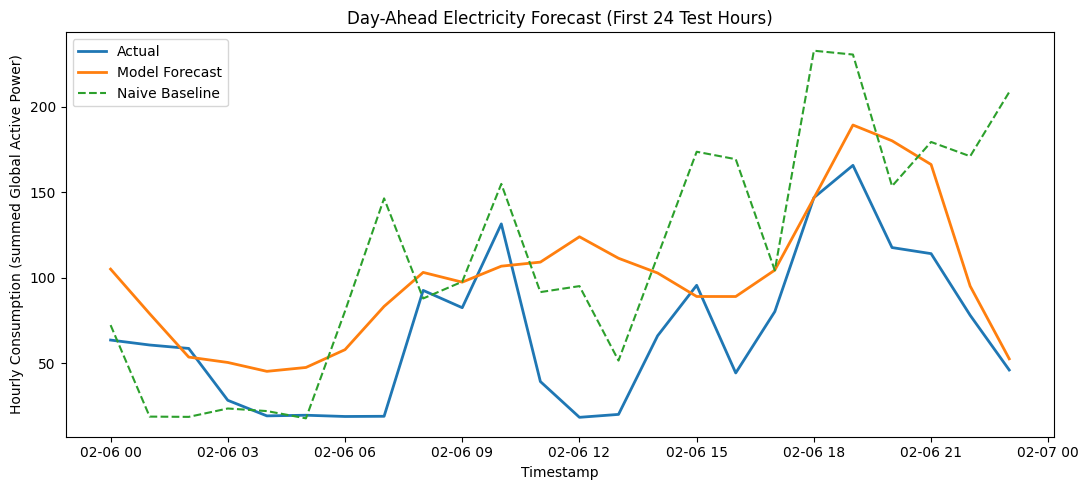

Saved plot: forecast_results_notebook.png


In [5]:
n = min(24, len(y_test))
idx = y_test.index[:n]

plt.figure(figsize=(11, 5))
plt.plot(idx, y_test.iloc[:n], label='Actual', linewidth=2)
plt.plot(idx, pred[:n], label='Model Forecast', linewidth=2)
plt.plot(idx, baseline.iloc[:n], label='Naive Baseline', linestyle='--')
plt.title('Day-Ahead Electricity Forecast (First 24 Test Hours)')
plt.xlabel('Timestamp')
plt.ylabel('Hourly Consumption (summed Global Active Power)')
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150)
plt.show()
print(f'Saved plot: {PLOT_PATH}')